# IMPORTING LIBRARIES

In [1]:
import re
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("amjath.txt", sep="argument", header=None, lineterminator='\n', encoding='utf-8', engine='python') 

# EXTRACTING THE MESSAGE COLUMN

In [4]:
if df.shape[1] > 3:
    messages = df[3].dropna().astype(str).tolist()
else:
    messages = df[0].dropna().astype(str).tolist()

# CLEAN AND COMBANING THE TEXT

In [5]:
cleaned = []
for msg in messages:
    msg = re.sub(r'http[s]?://\S+', '', msg)             
    if msg and '<Media omitted>' not in msg:            
        cleaned.append(msg.strip())
corpus = ' '.join(cleaned)

# GENERATING THE WORD CLOUD

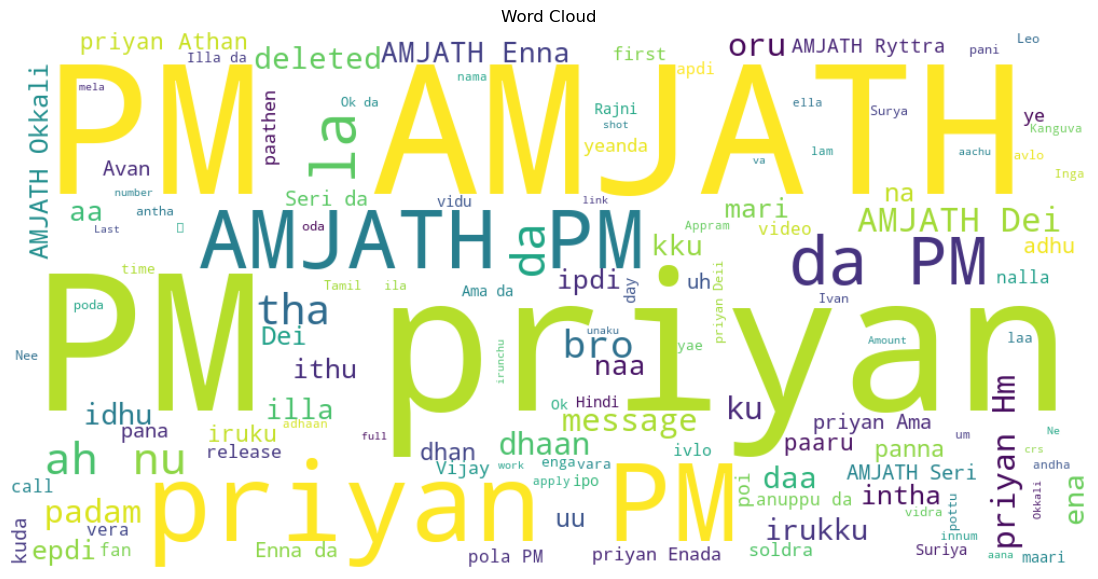

In [6]:
stopwords = set(STOPWORDS)
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords,
    collocations=True,
    min_font_size=10
).generate(corpus)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()